# Week 8 — Evaluation Expansion

## Objective

This notebook expands the evaluation of the final XGBoost Automated Valuation Model (AVM) developed in Week 7.

Rather than retraining the model, this analysis directly uses the saved June 2026 test-set predictions from the previous notebook.

The objectives are to:

1. Evaluate model performance using metrics beyond R², with particular emphasis on MAPE and MdAPE.
2. Examine prediction errors across different property price bands.
3. Identify price ranges in which the model performs relatively well or poorly.
4. Visualize the distribution and magnitude of prediction errors.
5. Save a consolidated evaluation table as `metrics_summary.csv`.

June 2026 remains the unseen test period used for final model evaluation.

## 1. Import Libraries and Define Paths

The Week 8 notebook loads the June 2026 predictions that were saved during Week 7 and performs additional evaluation directly from those predictions.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

sns.set(style="whitegrid")

pd.set_option(
    "display.max_columns",
    100
)

DATA_DIR = (
    "/content/drive/MyDrive/"
    "IDX_Exchange_Su26/data"
)

WEEK7_OUTPUT_DIR = os.path.join(
    DATA_DIR,
    "week7_outputs"
)

OUTPUT_DIR = os.path.join(
    DATA_DIR,
    "week8_outputs"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

PREDICTIONS_PATH = os.path.join(
    WEEK7_OUTPUT_DIR,
    "week7_xgboost_test_predictions.csv"
)

print(
    "Week 7 predictions:",
    PREDICTIONS_PATH
)

print(
    "Week 8 output directory:",
    OUTPUT_DIR
)

Week 7 predictions: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_test_predictions.csv
Week 8 output directory: /content/drive/MyDrive/IDX_Exchange_Su26/data/week8_outputs


## 2. Load Saved June 2026 Predictions

In [3]:
if not os.path.exists(
    PREDICTIONS_PATH
):
    raise FileNotFoundError(
        "Week 7 prediction file was not found:\n"
        f"{PREDICTIONS_PATH}\n\n"
        "This notebook requires the prediction CSV "
        "saved by Week 7, but does not require "
        "rerunning the Week 7 notebook."
    )

predictions_df = pd.read_csv(
    PREDICTIONS_PATH
)

print(
    "Prediction data loaded successfully."
)

print(
    "Shape:",
    predictions_df.shape
)

display(
    predictions_df.head()
)

Prediction data loaded successfully.
Shape: (12714, 2)


,Actual_ClosePrice,Predicted_ClosePrice
0,914000.0,1008682.56
1,1299000.0,1982142.90
2,598000.0,608915.10
3,1120000.0,1494527.50
4,640000.0,598334.70


## 3. Validate the Evaluation Data

Before calculating evaluation metrics, the prediction data are checked for missing values, invalid prices, and infinite values.

Only observations with valid positive actual and predicted closing prices are retained for the expanded evaluation.

In [4]:
required_columns = [
    "Actual_ClosePrice",
    "Predicted_ClosePrice"
]

missing_columns = [
    col
    for col in required_columns
    if col not in predictions_df.columns
]

if missing_columns:
    raise KeyError(
        "Required prediction columns are missing: "
        f"{missing_columns}"
    )

for col in required_columns:
    predictions_df[col] = pd.to_numeric(
        predictions_df[col],
        errors="coerce"
    )

print("Missing values before filtering:")

print(
    predictions_df[
        required_columns
    ].isna().sum()
)

predictions_df = predictions_df.replace(
    [np.inf, -np.inf],
    np.nan
)

predictions_df = predictions_df[
    predictions_df[
        "Actual_ClosePrice"
    ].notna()
    &
    predictions_df[
        "Predicted_ClosePrice"
    ].notna()
    &
    (
        predictions_df[
            "Actual_ClosePrice"
        ] > 0
    )
    &
    (
        predictions_df[
            "Predicted_ClosePrice"
        ] > 0
    )
].copy()

print(
    "\nValid evaluation observations:",
    len(predictions_df)
)

Missing values before filtering:
Actual_ClosePrice       0
Predicted_ClosePrice    0
dtype: int64

Valid evaluation observations: 12714


## 4. Calculate Property-Level Prediction Errors

Several property-level error measures are calculated to support the expanded evaluation.

For each property:

- **Error** = Predicted Price − Actual Price
- **Absolute Error** = |Predicted Price − Actual Price|
- **Percentage Error** indicates whether the model overestimated or underestimated the property.
- **Absolute Percentage Error (APE)** measures the magnitude of the prediction error relative to the actual closing price.

Positive percentage errors indicate overprediction, while negative percentage errors indicate underprediction.

In [5]:
predictions_df["Error"] = (
    predictions_df[
        "Predicted_ClosePrice"
    ]
    -
    predictions_df[
        "Actual_ClosePrice"
    ]
)

predictions_df["Absolute_Error"] = (
    predictions_df[
        "Error"
    ].abs()
)

predictions_df[
    "Percentage_Error"
] = (
    predictions_df[
        "Error"
    ]
    /
    predictions_df[
        "Actual_ClosePrice"
    ]
) * 100

predictions_df[
    "Absolute_Percentage_Error"
] = (
    predictions_df[
        "Percentage_Error"
    ].abs()
)

display(
    predictions_df.head()
)

,Actual_ClosePrice,Predicted_ClosePrice,Error,Absolute_Error,Percentage_Error,Absolute_Percentage_Error
0,914000.0,1008682.56,94682.56,94682.56,10.359142,10.359142
1,1299000.0,1982142.90,683142.90,683142.90,52.589908,52.589908
2,598000.0,608915.10,10915.10,10915.10,1.825268,1.825268
3,1120000.0,1494527.50,374527.50,374527.50,33.439955,33.439955
4,640000.0,598334.70,-41665.30,41665.30,-6.510203,6.510203


## 5. Overall June 2026 Test Performance

The model is evaluated using several complementary metrics.

- **R²** measures the proportion of variation in closing prices explained by the model.
- **MAE** measures the average absolute prediction error in dollars.
- **RMSE** measures prediction error in dollars while placing greater weight on large errors.
- **MAPE** measures the mean absolute percentage prediction error.
- **MdAPE** measures the median absolute percentage prediction error and is less sensitive to unusually large percentage errors than MAPE.

MAPE and MdAPE are particularly useful for the expanded evaluation because dollar errors naturally tend to be larger for more expensive properties.

In [6]:
y_true = predictions_df[
    "Actual_ClosePrice"
]

y_pred = predictions_df[
    "Predicted_ClosePrice"
]

overall_r2 = r2_score(
    y_true,
    y_pred
)

overall_mae = mean_absolute_error(
    y_true,
    y_pred
)

overall_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

overall_mape = (
    mean_absolute_percentage_error(
        y_true,
        y_pred
    )
    * 100
)

overall_mdape = (
    predictions_df[
        "Absolute_Percentage_Error"
    ].median()
)

overall_metrics_df = pd.DataFrame({
    "Metric": [
        "R2",
        "MAE",
        "RMSE",
        "MAPE",
        "MdAPE"
    ],

    "Value": [
        overall_r2,
        overall_mae,
        overall_rmse,
        overall_mape,
        overall_mdape
    ]
})

display(
    overall_metrics_df
)

,Metric,Value
0,R2,0.871927
1,MAE,189511.451977
2,RMSE,354459.779657
3,MAPE,15.488394
4,MdAPE,10.588940


## 6. Distribution of Absolute Percentage Errors

The distribution of Absolute Percentage Error (APE) shows how prediction accuracy varies across individual properties.

The mean corresponds to MAPE, while the median corresponds to MdAPE. Comparing these two values helps determine whether a relatively small number of large prediction errors are increasing the average error.

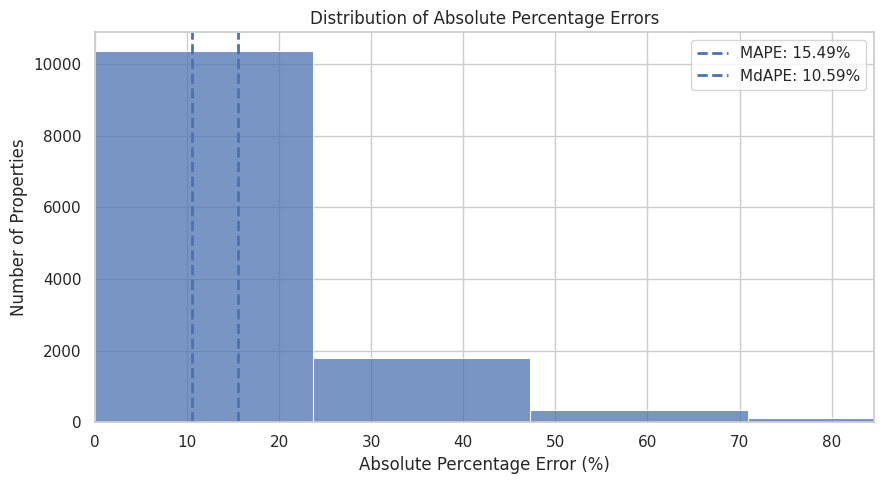

In [7]:
plt.figure(
    figsize=(9, 5)
)

sns.histplot(
    predictions_df[
        "Absolute_Percentage_Error"
    ],
    bins=60
)

plt.axvline(
    overall_mape,
    linestyle="--",
    linewidth=2,
    label=(
        f"MAPE: "
        f"{overall_mape:.2f}%"
    )
)

plt.axvline(
    overall_mdape,
    linestyle="--",
    linewidth=2,
    label=(
        f"MdAPE: "
        f"{overall_mdape:.2f}%"
    )
)

plt.title(
    "Distribution of Absolute Percentage Errors"
)

plt.xlabel(
    "Absolute Percentage Error (%)"
)

plt.ylabel(
    "Number of Properties"
)

plt.xlim(
    0,
    predictions_df[
        "Absolute_Percentage_Error"
    ].quantile(0.99)
)

plt.legend()

plt.tight_layout()

plt.show()

## 7. Prediction Accuracy Thresholds

To make the model's performance easier to interpret in practical terms, the percentage of June 2026 properties predicted within several error thresholds is calculated.

The analysis reports the share of predictions falling within:

- ±5% of the actual closing price;
- ±10%;
- ±15%;
- ±20%.

These measures complement R², MAPE, and MdAPE by showing how frequently the AVM produces predictions within practically meaningful error ranges.

In [8]:
accuracy_thresholds = [
    5,
    10,
    15,
    20
]

accuracy_results = []

for threshold in accuracy_thresholds:

    within_threshold = (
        predictions_df[
            "Absolute_Percentage_Error"
        ]
        <= threshold
    )

    accuracy_results.append({
        "Threshold_Percent":
            threshold,

        "Number_Within_Threshold":
            int(
                within_threshold.sum()
            ),

        "Percent_Within_Threshold":
            (
                within_threshold.mean()
                * 100
            )
    })

accuracy_threshold_df = pd.DataFrame(
    accuracy_results
)

display(
    accuracy_threshold_df
)

,Threshold_Percent,Number_Within_Threshold,Percent_Within_Threshold
0,5,3249,25.554507
1,10,6071,47.750511
2,15,8168,64.244140
3,20,9626,75.711814


## 8. Define Property Price Bands

To investigate whether prediction accuracy differs across market segments, properties are grouped according to their actual June 2026 closing prices.

The following price bands are used:

- Under $500K
- $500K–$750K
- $750K–$1M
- $1M–$1.5M
- $1.5M–$2M
- $2M+

Using fixed dollar ranges makes the results easier to interpret from a real-estate valuation perspective than data-dependent quantile groups.

In [9]:
price_bins = [
    0,
    500_000,
    750_000,
    1_000_000,
    1_500_000,
    2_000_000,
    np.inf
]

price_labels = [
    "Under $500K",
    "$500K-$750K",
    "$750K-$1M",
    "$1M-$1.5M",
    "$1.5M-$2M",
    "$2M+"
]

predictions_df[
    "Price_Band"
] = pd.cut(
    predictions_df[
        "Actual_ClosePrice"
    ],
    bins=price_bins,
    labels=price_labels,
    right=False
)

print(
    "Properties by price band:"
)

print(
    predictions_df[
        "Price_Band"
    ]
    .value_counts(
        sort=False
    )
)

Properties by price band:
Price_Band
Under $500K    1696
$500K-$750K    2696
$750K-$1M      2616
$1M-$1.5M      2574
$1.5M-$2M      1413
$2M+           1719
Name: count, dtype: int64


## 9. Model Performance by Price Band

Evaluation metrics are calculated separately for each actual closing-price band.

This analysis helps identify market segments where the AVM performs relatively well and segments where prediction is more difficult.

MAPE and MdAPE are especially useful for comparing price bands because they express errors relative to each property's actual value.

In [10]:
price_band_results = []

for band in price_labels:

    band_df = predictions_df[
        predictions_df[
            "Price_Band"
        ] == band
    ].copy()

    if len(band_df) == 0:
        continue

    band_y_true = band_df[
        "Actual_ClosePrice"
    ]

    band_y_pred = band_df[
        "Predicted_ClosePrice"
    ]

    if len(band_df) >= 2:
        band_r2 = r2_score(
            band_y_true,
            band_y_pred
        )
    else:
        band_r2 = np.nan

    band_mae = mean_absolute_error(
        band_y_true,
        band_y_pred
    )

    band_rmse = np.sqrt(
        mean_squared_error(
            band_y_true,
            band_y_pred
        )
    )

    band_mape = (
        band_df[
            "Absolute_Percentage_Error"
        ].mean()
    )

    band_mdape = (
        band_df[
            "Absolute_Percentage_Error"
        ].median()
    )

    median_actual_price = (
        band_df[
            "Actual_ClosePrice"
        ].median()
    )

    price_band_results.append({
        "Price_Band":
            band,

        "Number_of_Properties":
            len(band_df),

        "Median_Actual_Price":
            median_actual_price,

        "R2":
            band_r2,

        "MAE":
            band_mae,

        "RMSE":
            band_rmse,

        "MAPE":
            band_mape,

        "MdAPE":
            band_mdape
    })

price_band_metrics_df = pd.DataFrame(
    price_band_results
)

display(
    price_band_metrics_df
)

,Price_Band,Number_of_Properties,Median_Actual_Price,R2,MAE,RMSE,MAPE,MdAPE
0,Under $500K,1696,402000.0,-2.858254,85888.752282,144208.649479,24.129086,13.826036
1,$500K-$750K,2696,625000.0,-3.532422,86917.061869,153129.919320,14.062480,8.726358
2,$750K-$1M,2616,860000.0,-4.171444,109434.983035,163509.027629,12.633065,9.118371
3,$1M-$1.5M,2574,1215200.0,-2.410113,172193.157335,253953.196898,14.115209,10.585546
4,$1.5M-$2M,1413,1690000.0,-4.853601,245615.312597,339437.638594,14.376741,11.131514
5,$2M+,1719,2775000.0,0.600335,554328.876358,800005.709399,16.514887,13.603036


## 10. MAPE Across Price Bands

MAPE provides a scale-independent comparison of prediction accuracy across different property-value segments.

Lower MAPE indicates better relative prediction accuracy.

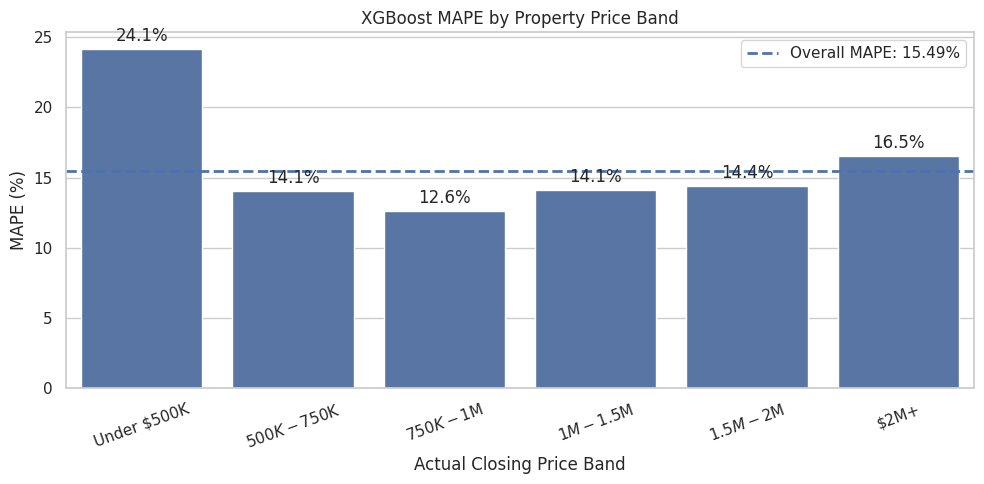

In [11]:
plt.figure(
    figsize=(10, 5)
)

ax = sns.barplot(
    data=price_band_metrics_df,
    x="Price_Band",
    y="MAPE"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.axhline(
    overall_mape,
    linestyle="--",
    linewidth=2,
    label=(
        f"Overall MAPE: "
        f"{overall_mape:.2f}%"
    )
)

plt.title(
    "XGBoost MAPE by Property Price Band"
)

plt.xlabel(
    "Actual Closing Price Band"
)

plt.ylabel(
    "MAPE (%)"
)

plt.xticks(
    rotation=20
)

plt.legend()

plt.tight_layout()

plt.show()

## 11. MdAPE Across Price Bands

MdAPE represents the typical absolute percentage error within each price segment and is less influenced by extreme prediction errors than MAPE.

Comparing MAPE and MdAPE can reveal price segments where a small number of unusually difficult properties substantially increase the average error.

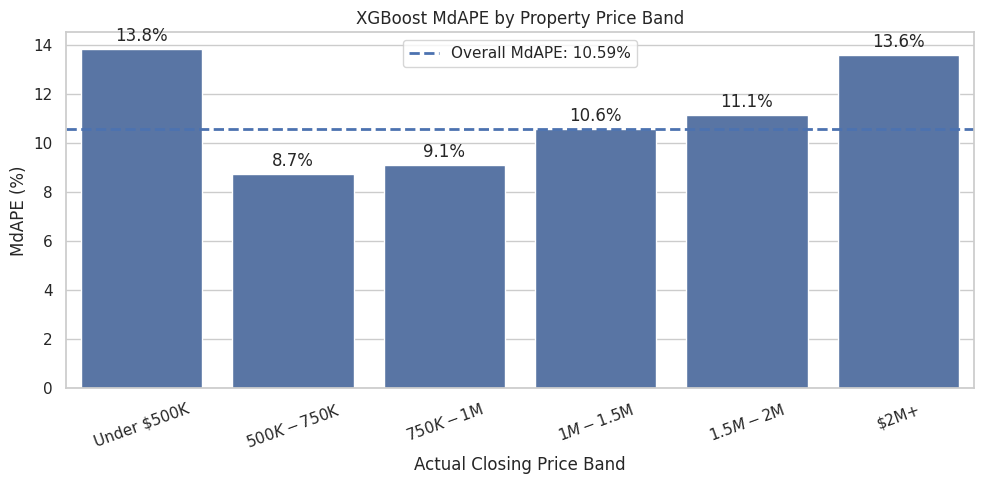

In [12]:
plt.figure(
    figsize=(10, 5)
)

ax = sns.barplot(
    data=price_band_metrics_df,
    x="Price_Band",
    y="MdAPE"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.axhline(
    overall_mdape,
    linestyle="--",
    linewidth=2,
    label=(
        f"Overall MdAPE: "
        f"{overall_mdape:.2f}%"
    )
)

plt.title(
    "XGBoost MdAPE by Property Price Band"
)

plt.xlabel(
    "Actual Closing Price Band"
)

plt.ylabel(
    "MdAPE (%)"
)

plt.xticks(
    rotation=20
)

plt.legend()

plt.tight_layout()

plt.show()

## 12. Dollar Prediction Error Across Price Bands

MAE measures the average dollar difference between predicted and actual closing prices.

Unlike percentage-based metrics, MAE shows the absolute financial magnitude of model errors. This is useful because higher-priced properties may have relatively low percentage errors while still producing large dollar errors.

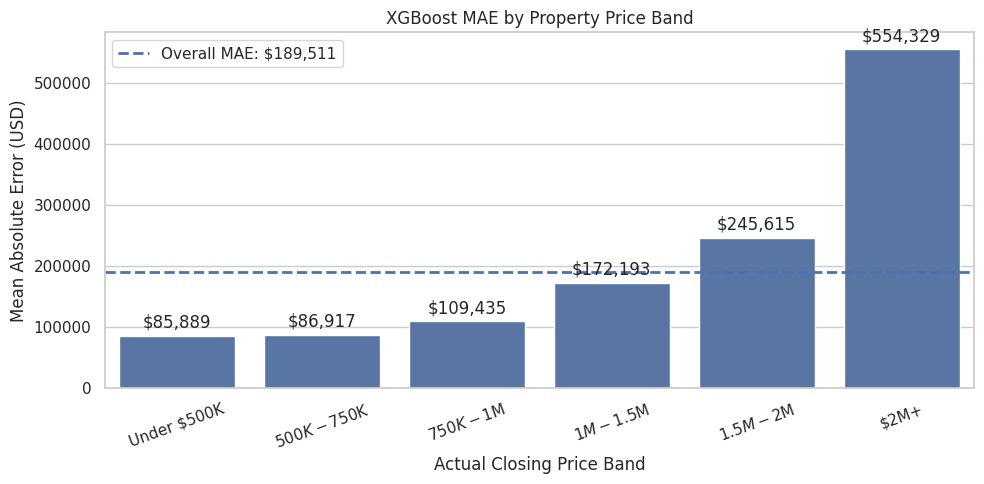

In [13]:
plt.figure(
    figsize=(10, 5)
)

ax = sns.barplot(
    data=price_band_metrics_df,
    x="Price_Band",
    y="MAE"
)

for container in ax.containers:
    labels = [
        f"${value:,.0f}"
        for value
        in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3
    )

plt.axhline(
    overall_mae,
    linestyle="--",
    linewidth=2,
    label=(
        "Overall MAE: "
        f"${overall_mae:,.0f}"
    )
)

plt.title(
    "XGBoost MAE by Property Price Band"
)

plt.xlabel(
    "Actual Closing Price Band"
)

plt.ylabel(
    "Mean Absolute Error (USD)"
)

plt.xticks(
    rotation=20
)

plt.legend()

plt.tight_layout()

plt.show()

## 13. Overprediction and Underprediction

Prediction direction is examined to determine whether the AVM systematically tends to overestimate or underestimate closing prices.

A positive error indicates that the predicted value exceeded the actual closing price, while a negative error indicates underprediction.

In [14]:
predictions_df[
    "Prediction_Direction"
] = np.where(
    predictions_df[
        "Error"
    ] > 0,
    "Overprediction",
    np.where(
        predictions_df[
            "Error"
        ] < 0,
        "Underprediction",
        "Exact"
    )
)

direction_summary_df = (
    predictions_df[
        "Prediction_Direction"
    ]
    .value_counts()
    .rename_axis(
        "Prediction_Direction"
    )
    .reset_index(
        name="Count"
    )
)

direction_summary_df[
    "Percent"
] = (
    direction_summary_df[
        "Count"
    ]
    /
    len(predictions_df)
    * 100
)

display(
    direction_summary_df
)

,Prediction_Direction,Count,Percent
0,Overprediction,6825,53.680982
1,Underprediction,5889,46.319018


## 14. Prediction Bias by Price Band

The mean signed percentage error is calculated for each price band to examine systematic valuation bias.

- A positive value indicates average overvaluation.
- A negative value indicates average undervaluation.
- A value close to zero indicates relatively little systematic directional bias.

In [15]:
bias_by_band_df = (
    predictions_df
    .groupby(
        "Price_Band",
        observed=True
    )
    .agg(
        Number_of_Properties=(
            "Actual_ClosePrice",
            "size"
        ),

        Mean_Percentage_Error=(
            "Percentage_Error",
            "mean"
        ),

        Median_Percentage_Error=(
            "Percentage_Error",
            "median"
        )
    )
    .reset_index()
)

display(
    bias_by_band_df
)

,Price_Band,Number_of_Properties,Mean_Percentage_Error,Median_Percentage_Error
0,Under $500K,1696,19.239147,10.696753
1,$500K-$750K,2696,8.540017,4.113301
2,$750K-$1M,2616,5.002711,2.333900
3,$1M-$1.5M,2574,2.210144,-0.568664
4,$1.5M-$2M,1413,-0.383005,-2.618536
5,$2M+,1719,-7.354804,-8.990122


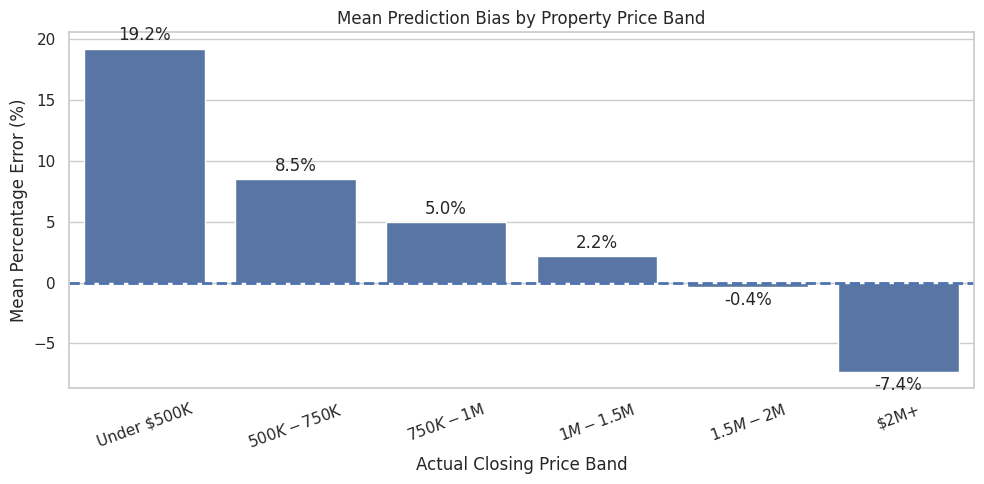

In [16]:
plt.figure(
    figsize=(10, 5)
)

ax = sns.barplot(
    data=bias_by_band_df,
    x="Price_Band",
    y="Mean_Percentage_Error"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title(
    "Mean Prediction Bias by Property Price Band"
)

plt.xlabel(
    "Actual Closing Price Band"
)

plt.ylabel(
    "Mean Percentage Error (%)"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

## 15. Largest Percentage Prediction Errors

The observations with the largest absolute percentage errors are examined to identify cases in which the model performs particularly poorly.

These cases may represent unusual properties, sparse market segments, or observations whose characteristics are not well represented in the training data.

In [17]:
worst_predictions_df = (
    predictions_df[
        [
            "Actual_ClosePrice",
            "Predicted_ClosePrice",
            "Error",
            "Absolute_Error",
            "Percentage_Error",
            "Absolute_Percentage_Error",
            "Price_Band"
        ]
    ]
    .sort_values(
        "Absolute_Percentage_Error",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

display(
    worst_predictions_df
)

,Actual_ClosePrice,Predicted_ClosePrice,Error,Absolute_Error,Percentage_Error,Absolute_Percentage_Error,Price_Band
0,190000.0,2883951.20,2693951.20,2693951.20,1417.869053,1417.869053,Under $500K
1,233000.0,1495468.80,1262468.80,1262468.80,541.832103,541.832103,Under $500K
2,1000000.0,5540993.50,4540993.50,4540993.50,454.099350,454.099350,$1M-$1.5M
3,700000.0,3563717.50,2863717.50,2863717.50,409.102500,409.102500,$500K-$750K
4,650000.0,3033779.80,2383779.80,2383779.80,366.735354,366.735354,$500K-$750K
5,640000.0,2567434.00,1927434.00,1927434.00,301.161563,301.161563,$500K-$750K
6,890000.0,3515887.00,2625887.00,2625887.00,295.043483,295.043483,$750K-$1M
7,460000.0,1547631.40,1087631.40,1087631.40,236.441609,236.441609,Under $500K
8,600000.0,1896988.20,1296988.20,1296988.20,216.164700,216.164700,$500K-$750K
9,265000.0,768938.75,503938.75,503938.75,190.165566,190.165566,Under $500K


## 16. Create the Evaluation Metrics Summary

A consolidated metrics table is created for the Week 8 deliverable.

The first row reports overall June 2026 performance. The remaining rows report performance within each property price band.

This allows both overall and segment-level model performance to be reviewed in a single file.

In [18]:
overall_summary = pd.DataFrame({
    "Evaluation_Group": [
        "Overall"
    ],

    "Number_of_Properties": [
        len(predictions_df)
    ],

    "R2": [
        overall_r2
    ],

    "MAE": [
        overall_mae
    ],

    "RMSE": [
        overall_rmse
    ],

    "MAPE": [
        overall_mape
    ],

    "MdAPE": [
        overall_mdape
    ]
})

band_summary = (
    price_band_metrics_df[
        [
            "Price_Band",
            "Number_of_Properties",
            "R2",
            "MAE",
            "RMSE",
            "MAPE",
            "MdAPE"
        ]
    ]
    .rename(
        columns={
            "Price_Band":
                "Evaluation_Group"
        }
    )
)

metrics_summary_df = pd.concat(
    [
        overall_summary,
        band_summary
    ],
    ignore_index=True
)

display(
    metrics_summary_df
)

,Evaluation_Group,Number_of_Properties,R2,MAE,RMSE,MAPE,MdAPE
0,Overall,12714,0.871927,189511.451977,354459.779657,15.488394,10.588940
1,Under $500K,1696,-2.858254,85888.752282,144208.649479,24.129086,13.826036
2,$500K-$750K,2696,-3.532422,86917.061869,153129.919320,14.062480,8.726358
3,$750K-$1M,2616,-4.171444,109434.983035,163509.027629,12.633065,9.118371
4,$1M-$1.5M,2574,-2.410113,172193.157335,253953.196898,14.115209,10.585546
5,$1.5M-$2M,1413,-4.853601,245615.312597,339437.638594,14.376741,11.131514
6,$2M+,1719,0.600335,554328.876358,800005.709399,16.514887,13.603036


## 17. Save Week 8 Evaluation Outputs

The consolidated evaluation metrics are saved as `metrics_summary.csv`, the required Week 8 deliverable.

Additional detailed outputs are also saved to support later analysis without requiring this notebook to be rerun.

In [19]:
METRICS_SUMMARY_PATH = os.path.join(
    OUTPUT_DIR,
    "metrics_summary.csv"
)

DETAILED_PREDICTIONS_PATH = os.path.join(
    OUTPUT_DIR,
    "evaluation_predictions_detailed.csv"
)

PRICE_BAND_METRICS_PATH = os.path.join(
    OUTPUT_DIR,
    "price_band_metrics.csv"
)

ACCURACY_THRESHOLD_PATH = os.path.join(
    OUTPUT_DIR,
    "accuracy_thresholds.csv"
)

BIAS_PATH = os.path.join(
    OUTPUT_DIR,
    "price_band_bias.csv"
)

metrics_summary_df.to_csv(
    METRICS_SUMMARY_PATH,
    index=False
)

predictions_df.to_csv(
    DETAILED_PREDICTIONS_PATH,
    index=False
)

price_band_metrics_df.to_csv(
    PRICE_BAND_METRICS_PATH,
    index=False
)

accuracy_threshold_df.to_csv(
    ACCURACY_THRESHOLD_PATH,
    index=False
)

bias_by_band_df.to_csv(
    BIAS_PATH,
    index=False
)

print(
    "Saved metrics summary:"
)

print(
    METRICS_SUMMARY_PATH
)

print(
    "\nSaved detailed predictions:"
)

print(
    DETAILED_PREDICTIONS_PATH
)

print(
    "\nSaved price-band metrics:"
)

print(
    PRICE_BAND_METRICS_PATH
)

Saved metrics summary:
/content/drive/MyDrive/IDX_Exchange_Su26/data/week8_outputs/metrics_summary.csv

Saved detailed predictions:
/content/drive/MyDrive/IDX_Exchange_Su26/data/week8_outputs/evaluation_predictions_detailed.csv

Saved price-band metrics:
/content/drive/MyDrive/IDX_Exchange_Su26/data/week8_outputs/price_band_metrics.csv


## 18. Identify the Best- and Worst-Performing Price Segments

The price bands with the lowest MAPE and MdAPE are identified as the strongest relative-performing segments.

The price band with the highest MAPE is also identified to highlight where the model has the greatest relative prediction difficulty.

In [20]:
best_mape_row = (
    price_band_metrics_df
    .loc[
        price_band_metrics_df[
            "MAPE"
        ].idxmin()
    ]
)

best_mdape_row = (
    price_band_metrics_df
    .loc[
        price_band_metrics_df[
            "MdAPE"
        ].idxmin()
    ]
)

worst_mape_row = (
    price_band_metrics_df
    .loc[
        price_band_metrics_df[
            "MAPE"
        ].idxmax()
    ]
)

print(
    "Best price band by MAPE:"
)

print(
    best_mape_row[
        "Price_Band"
    ],
    f"({best_mape_row['MAPE']:.2f}%)"
)

print(
    "\nBest price band by MdAPE:"
)

print(
    best_mdape_row[
        "Price_Band"
    ],
    f"({best_mdape_row['MdAPE']:.2f}%)"
)

print(
    "\nWorst price band by MAPE:"
)

print(
    worst_mape_row[
        "Price_Band"
    ],
    f"({worst_mape_row['MAPE']:.2f}%)"
)

Best price band by MAPE:
$750K-$1M (12.63%)

Best price band by MdAPE:
$500K-$750K (8.73%)

Worst price band by MAPE:
Under $500K (24.13%)


In [21]:
print(
    "WEEK 8 EVALUATION SUMMARY"
)

print("=" * 70)

print(
    "Evaluation month: June 2026"
)

print(
    "Model: XGBoost Regressor"
)

print(
    "Number of test properties:",
    len(predictions_df)
)

print("\nOverall performance:")

print(
    f"R²: {overall_r2:.4f}"
)

print(
    f"MAE: ${overall_mae:,.2f}"
)

print(
    f"RMSE: ${overall_rmse:,.2f}"
)

print(
    f"MAPE: {overall_mape:.2f}%"
)

print(
    f"MdAPE: {overall_mdape:.2f}%"
)

print(
    "\nBest price band by MAPE:"
)

print(
    best_mape_row[
        "Price_Band"
    ],
    f"({best_mape_row['MAPE']:.2f}%)"
)

print(
    "\nBest price band by MdAPE:"
)

print(
    best_mdape_row[
        "Price_Band"
    ],
    f"({best_mdape_row['MdAPE']:.2f}%)"
)

print(
    "\nWorst price band by MAPE:"
)

print(
    worst_mape_row[
        "Price_Band"
    ],
    f"({worst_mape_row['MAPE']:.2f}%)"
)

print(
    "\nDeliverable saved to:"
)

print(
    METRICS_SUMMARY_PATH
)

WEEK 8 EVALUATION SUMMARY
Evaluation month: June 2026
Model: XGBoost Regressor
Number of test properties: 12714

Overall performance:
R²: 0.8719
MAE: $189,511.45
RMSE: $354,459.78
MAPE: 15.49%
MdAPE: 10.59%

Best price band by MAPE:
$750K-$1M (12.63%)

Best price band by MdAPE:
$500K-$750K (8.73%)

Worst price band by MAPE:
Under $500K (24.13%)

Deliverable saved to:
/content/drive/MyDrive/IDX_Exchange_Su26/data/week8_outputs/metrics_summary.csv


## Conclusion

The Week 8 evaluation expanded the assessment of the final XGBoost AVM beyond R² by examining both overall and segment-level prediction errors.

On the June 2026 unseen test set, the model achieved:

* R²: **0.8719**
* MAE: **$189,511.45**

* RMSE: **$354,459.78**
* MAPE: **15.49%**
* MdAPE: **10.59%**

The difference between MAPE and MdAPE indicates that the distribution of percentage errors is right-skewed. The median prediction error was lower than the average prediction error, suggesting that most properties were predicted more accurately than the overall MAPE implies, while a smaller number of properties with relatively large errors increased the mean percentage error.

Performance also varied across property price bands. The **$750K to $1M** segment achieved the lowest _MAPE_ at **12.63%**, while the lower than $500K segment had the highest _MAPE_ at 24.13%.

The **$500K to $750K** segment achieved the lowest MdAPE at **8.73%**, indicating strong typical prediction accuracy within that price range.

The price-band analysis therefore suggests that the model performs most reliably for **mid-priced properties, particularly homes** between $500K and $1M, while lower-priced properties under $500K remain more difficult to predict accurately on a percentage basis.

Overall, the expanded evaluation shows that R² alone does not fully describe AVM performance. Although the model explains approximately **87.2%** of the variation in June 2026 closing prices, MAPE, MdAPE, and price-segment analysis reveal meaningful differences in practical prediction accuracy across the housing market. These results highlight the importance of evaluating both overall model fit and segment-level errors when assessing the real-world performance of an automated valuation model.
